In [6]:
import rasterio
from rasterio.plot import show

from pathlib import Path

import requests

import pandas as pd

In [5]:
SAVE_BASE = Path.cwd()
DOWNLOAD_URL = "http://206.12.92.143/data/dashboard/" #CAWA/Canada/CAWA_Canada_1990.tif"
DATA_URL = SAVE_BASE / "data"
CACHE_DIR = Path.cwd() / "tif_cache"
CACHE_DIR.mkdir(exist_ok=True)

def tif_path_local(code, country, year):
    return CACHE_DIR / f"{code}_{country}_{year}.tif"

def get_data(url, code, country, year):
    path = tif_path_local(code, country, year)

    if path.exists():
        return path

    response = requests.get(f"{url}/{code}/{country}/{code}_{country}_{year}.tif", stream=True)

    if response.status_code == 200:
        with open(path, 'wb') as file:
            for chunk in response.iter_content(1024):
                file.write(chunk)
        # data = BytesIO(response.content)
        # print("Data retrieved!")
        # return data
        # with tempfile.NamedTemporaryFile(delete=True) as tmp:
        #     tmp.write(response.content)
        #     tmp.flush()
        # return tmp.name
    else:
        print(f"Failed to retrieve data {response.status_code}")
    return path

In [3]:
data = get_data(DOWNLOAD_URL, "CAWA", "Canada", "2020")

In [ ]:
file = rasterio.open(data)
file.closed()

In [ ]:
file.crs

CRS.from_wkt('PROJCS["WGS 84 / Pseudo-Mercator",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Mercator_1SP"],PARAMETER["central_meridian",0],PARAMETER["scale_factor",1],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],EXTENSION["PROJ4","+proj=merc +a=6378137 +b=6378137 +lat_ts=0 +lon_0=0 +x_0=0 +y_0=0 +k=1 +units=m +nadgrids=@null +wktext +no_defs"],AUTHORITY["EPSG","3857"]]')

In [2]:
yesterday = rasterio.open("CAWA_Canada_1990.tif")

In [3]:
yesterday.crs

CRS.from_wkt('PROJCS["WGS 84 / Pseudo-Mercator",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Mercator_1SP"],PARAMETER["central_meridian",0],PARAMETER["scale_factor",1],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],EXTENSION["PROJ4","+proj=merc +a=6378137 +b=6378137 +lat_ts=0 +lon_0=0 +x_0=0 +y_0=0 +k=1 +units=m +nadgrids=@null +wktext +no_defs"],AUTHORITY["EPSG","3857"]]')

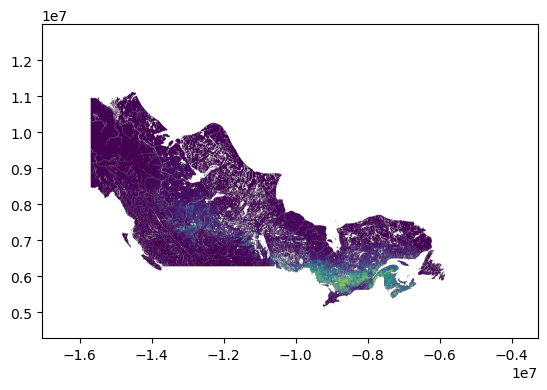

<Axes: >

In [4]:
show(rasterio.open(data))

In [10]:
species_url = "SpeciesData_Rounded.csv"

In [11]:
species_data = pd.read_csv(species_url)

In [12]:
species_data.shape

(1451330, 155)

In [13]:
SAVE_BASE = Path.cwd()
DOWNLOAD_URL = "http://206.12.92.143/data/dashboard/"
DATA_URL = SAVE_BASE / "data"

CACHE_DIR = Path.cwd() / "tif_cache"
CACHE_DIR.mkdir(exist_ok=True)

def tif_path_local(code, country, year):
    return CACHE_DIR / f"{code}_{country}_{year}.tif"

def get_data():
    path = "here/"

    if path.exists():
        return path

    response = requests.get(f"{DOWNLOAD_URL}", stream=True)

    if response.status_code == 200:
        with open(path, 'wb') as file:
            for chunk in response.iter_content(1024):
                file.write(chunk)
    else:
        print(f"Failed to retrieve data {response.status_code}")
    return path

In [14]:
data2 = get_data()

AttributeError: 'str' object has no attribute 'exists'

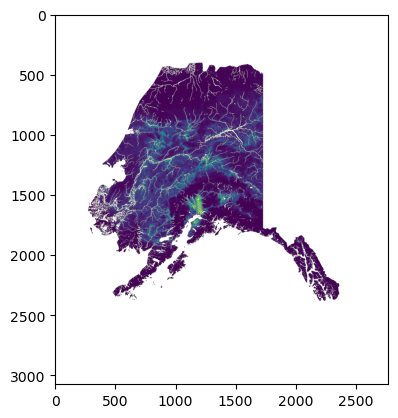

In [18]:
with rasterio.open("http://206.12.92.143/data/dashboard/ALFL/Alaska/ALFL_Alaska_1990.tif") as dataset:
    # Read the data for the entire raster (or a specific window)
    data = dataset.read(1)
    show(data)